In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif', 'Liberation Serif']

In [ ]:
#Creating data for xor
X = np.array([
    [1, 0, 0],
    [1, 0, 1],
    [1, 1, 0],
    [1, 1, 1]
])

y = np.array([
    0,
    1,
    1,
    0
])

In [ ]:
#Initilize weights
weights = np.zeros(3)
print(weights)

[0. 0. 0.]


In [ ]:
#Activation function
def step_func(x):
  if x >= 0:
    return 1
  return 0

In [ ]:
#To plot the graph
def plot_decision_boundary(X, y, weights, title, filename=None):
    plt.figure(figsize=(8,6))
    # Class 0
    plt.scatter(X[y==0,1],X[y==0,2],color='red',marker='o',s=100,edgecolors='black',label='Class 0')
    # Class 1
    plt.scatter(X[y==1,1],X[y==1,2],color='blue',marker='^',s=100,edgecolors='black',label='Class 1')
    if weights[2] != 0:
        x1 = np.linspace(-0.5, 1.5, 100)
        x2 = -(weights[0] + weights[1]*x1) / weights[2]
        plt.plot(x1,x2,color='green',linewidth=2,label='Decision Boundary')
        equation = f"{weights[0]:.2f} + {weights[1]:.2f}x₁ + {weights[2]:.2f}x₂ = 0"
        plt.text(-0.45,1.35,equation,fontsize=10,fontweight='bold',bbox=dict(facecolor='white', edgecolor='black'))

    plt.xlim(-0.5,1.5)
    plt.ylim(-0.5,1.5)
    plt.xticks([0,1])
    plt.yticks([0,1])

    plt.xlabel("Input x₁", fontweight='bold')
    plt.ylabel("Input x₂", fontweight='bold')
    plt.title(title, fontweight='bold')

    plt.grid(True)
    plt.legend()

    plt.tight_layout()

    if filename is not None:
        plt.savefig(filename,dpi=600,format="eps",bbox_inches="tight")
    plt.show()

In [ ]:
# TO do the forward pass and weight update rule
def train_or_perceptron(X, y, weights, learning_rate=0.5, epochs=3):
  for epoch in range(epochs):
    miss_class = 0
    print("Epoch:", epoch)
    for i in range(len(X)):
      x = X[i]
      y_pred = step_func(np.dot(weights, x))
      error = y[i] - y_pred
      weights = weights + learning_rate * error * x
      print(weights)

      if error != 0:
        miss_class += 1
        plot_decision_boundary(X,y,weights,f"XOR Decision Boundary - Epoch {epoch+1}",f"XOR_Epoch_{epoch+1}_Update_{i+1}.eps")
    if miss_class == 0:
      break
  return weights

Epoch: 0
[-0.5  0.   0. ]


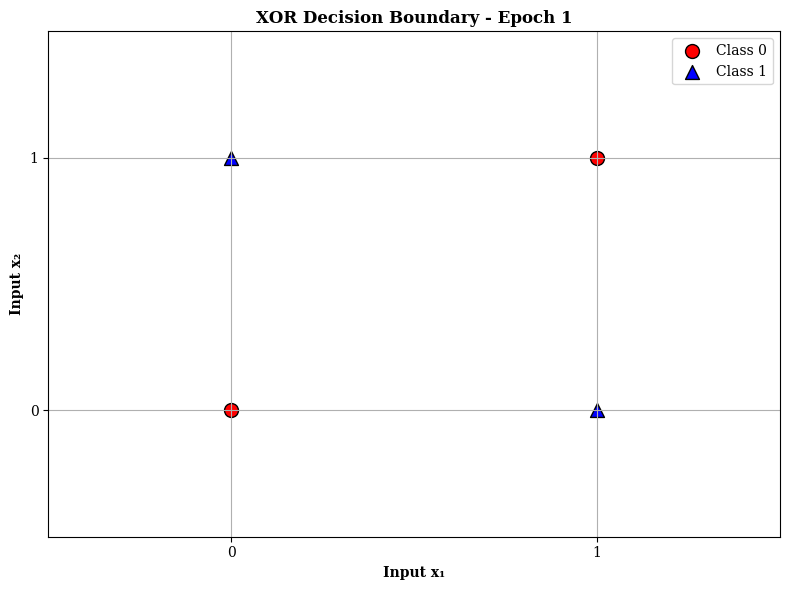

[0.  0.  0.5]


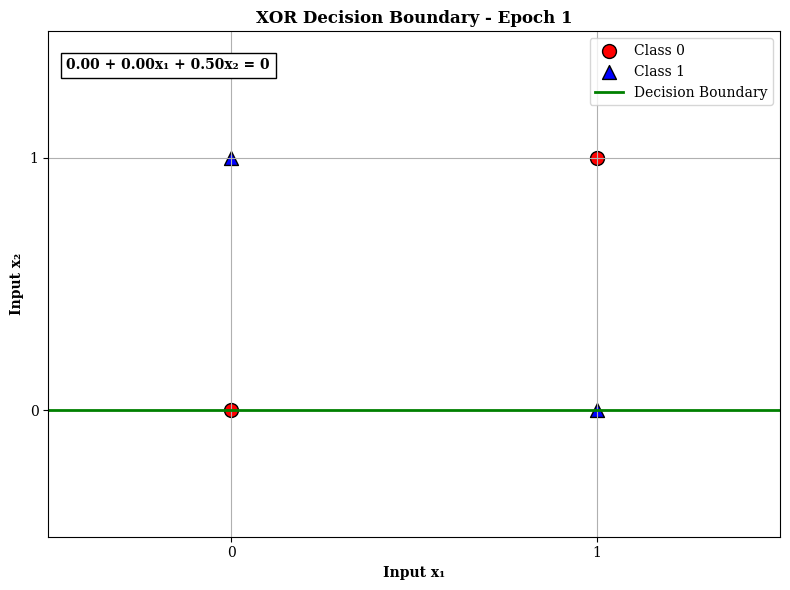

[0.  0.  0.5]
[-0.5 -0.5  0. ]


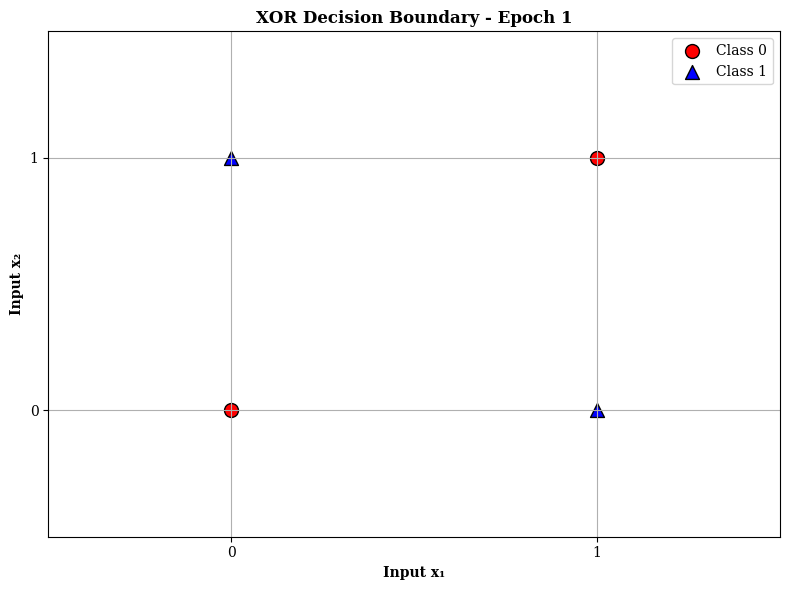

Epoch: 1
[-0.5 -0.5  0. ]
[ 0.  -0.5  0.5]


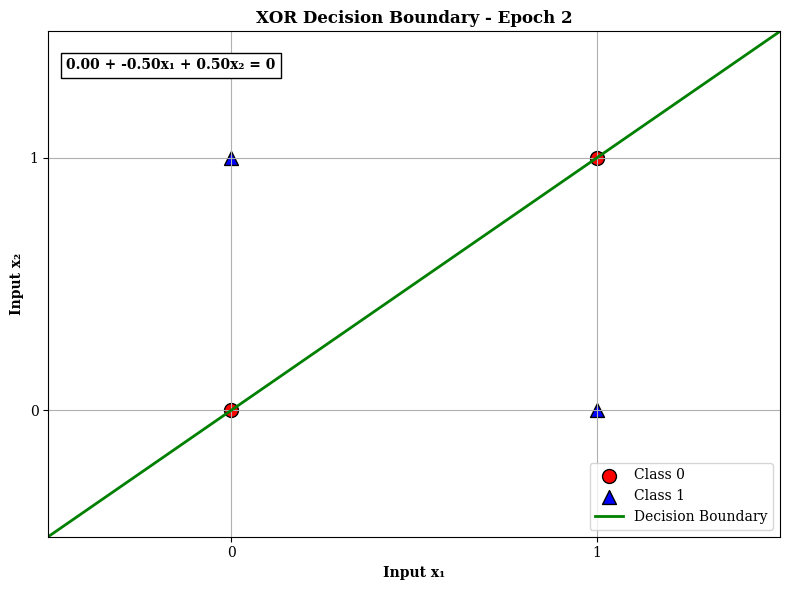

[0.5 0.  0.5]


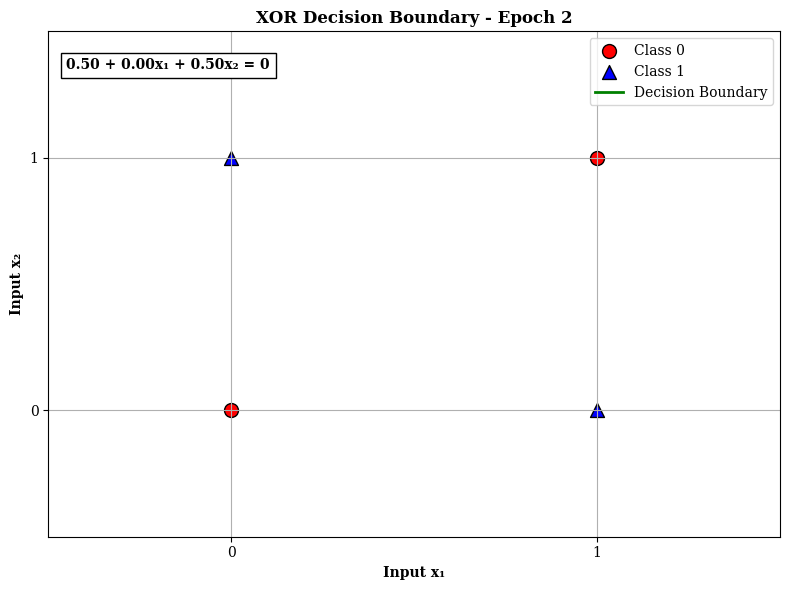

[ 0.  -0.5  0. ]


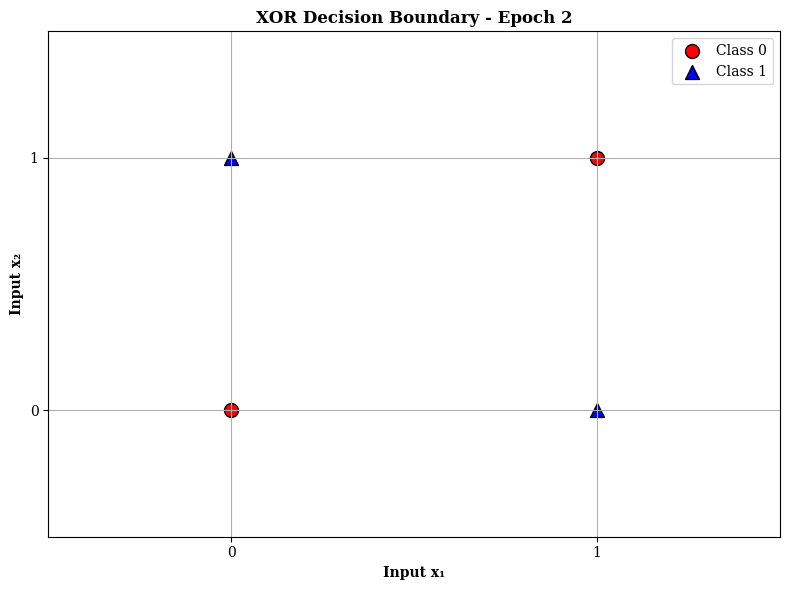

Epoch: 2
[-0.5 -0.5  0. ]


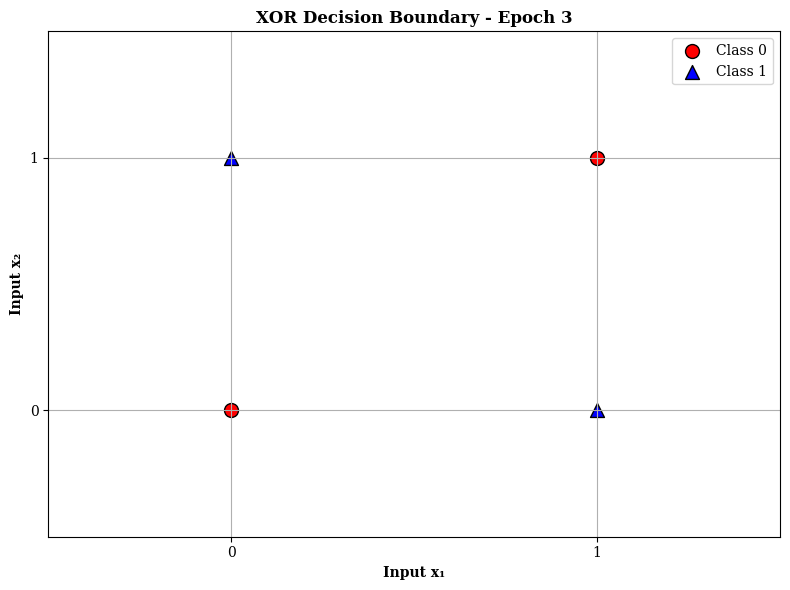

[ 0.  -0.5  0.5]


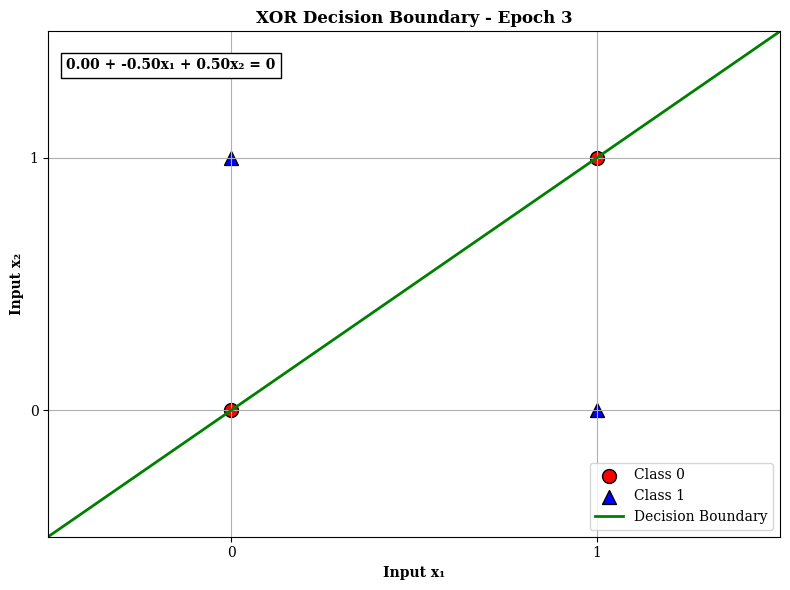

[0.5 0.  0.5]


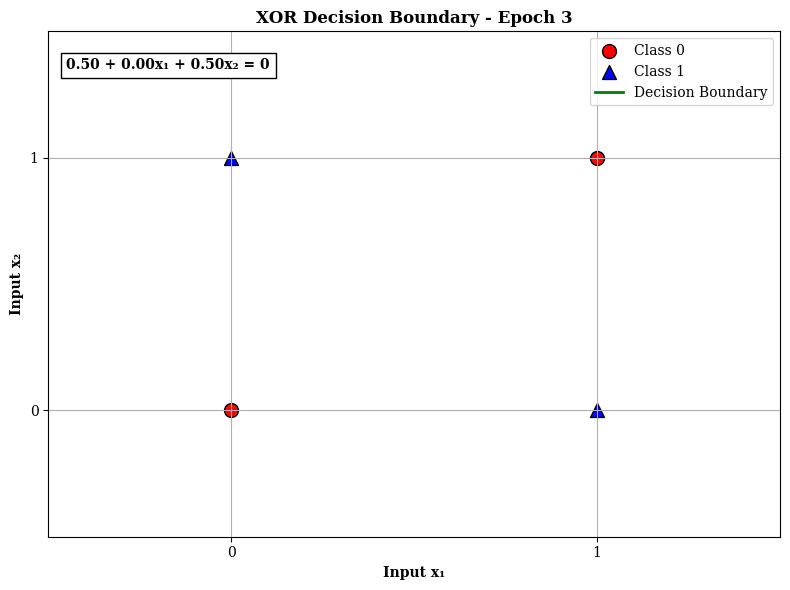

[ 0.  -0.5  0. ]


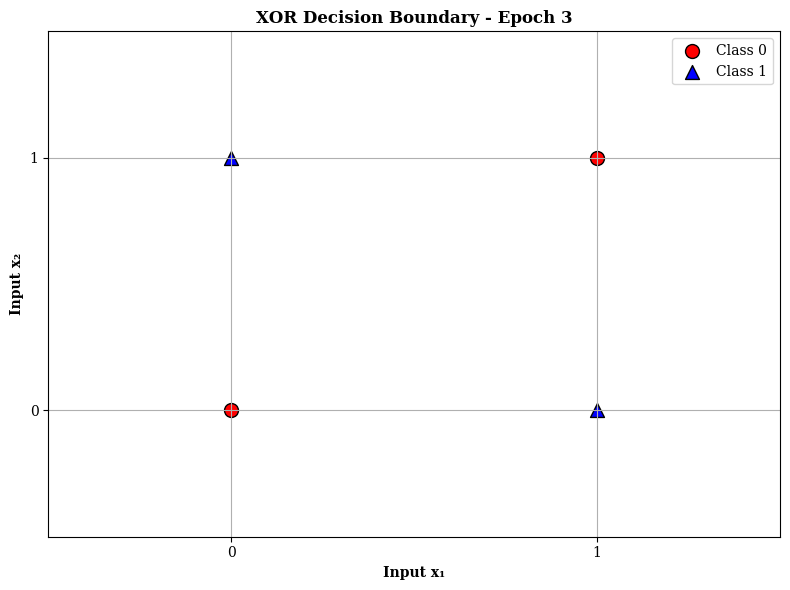

[ 0.  -0.5  0. ]


In [ ]:
# Train the model
weights = np.zeros(3,)
we = train_or_perceptron(X, y, weights)
print(we)

In [ ]:
#validate the model
correct = 0
for i in range(len(X)):
    x = X[i]
    y_pred = step_func(np.dot(we, x))
    if y_pred == y[i]:
        correct += 1

print("Accuracy:", correct, "/", len(X))

Accuracy: 2 / 4


In [ ]:

X_mlp = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_mlp = np.array([
    [0],
    [1],
    [1],
    [0]
])

In [ ]:

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(a):
    return a * (1 - a)

In [ ]:

np.random.seed(42)

input_size = 2
hidden_size = 2
output_size = 1

W1 = np.random.uniform(-1, 1, (input_size, hidden_size))
b1 = np.zeros((1, hidden_size))
W2 = np.random.uniform(-1, 1, (hidden_size, output_size))
b2 = np.zeros((1, output_size))

In [ ]:

def train_mlp_xor(X, y, W1, b1, W2, b2, learning_rate=0.5, epochs=10000):
    loss_history = []

    for epoch in range(epochs):
        z1 = np.dot(X, W1) + b1
        a1 = sigmoid(z1)
        z2 = np.dot(a1, W2) + b2
        a2 = sigmoid(z2)

        loss = np.mean((y - a2) ** 2)
        loss_history.append(loss)

        d_a2 = (a2 - y)
        d_z2 = d_a2 * sigmoid_derivative(a2)
        d_W2 = np.dot(a1.T, d_z2)
        d_b2 = np.sum(d_z2, axis=0, keepdims=True)

        d_a1 = np.dot(d_z2, W2.T)
        d_z1 = d_a1 * sigmoid_derivative(a1)
        d_W1 = np.dot(X.T, d_z1)
        d_b1 = np.sum(d_z1, axis=0, keepdims=True)

        W2 -= learning_rate * d_W2
        b2 -= learning_rate * d_b2
        W1 -= learning_rate * d_W1
        b1 -= learning_rate * d_b1

        if epoch % 1000 == 0:
            print(f"Epoch {epoch:5d}  Loss: {loss:.5f}")

    return W1, b1, W2, b2, loss_history

W1, b1, W2, b2, loss_history = train_mlp_xor(X_mlp, y_mlp, W1, b1, W2, b2,
                                              learning_rate=0.5, epochs=10000)

Epoch     0  Loss: 0.28630
Epoch  1000  Loss: 0.24244
Epoch  2000  Loss: 0.00982
Epoch  3000  Loss: 0.00351
Epoch  4000  Loss: 0.00208
Epoch  5000  Loss: 0.00146
Epoch  6000  Loss: 0.00112
Epoch  7000  Loss: 0.00091
Epoch  8000  Loss: 0.00076
Epoch  9000  Loss: 0.00065


In [ ]:

def predict(X, W1, b1, W2, b2):
    a1 = sigmoid(np.dot(X, W1) + b1)
    a2 = sigmoid(np.dot(a1, W2) + b2)
    return a2

preds = predict(X_mlp, W1, b1, W2, b2)
pred_labels = (preds >= 0.5).astype(int)
accuracy = np.mean(pred_labels == y_mlp) * 100

print("Raw outputs:\n", np.round(preds, 3))
print("Predicted labels:\n", pred_labels.ravel())
print("Accuracy:", accuracy, "%")

Raw outputs:
 [[0.023]
 [0.974]
 [0.974]
 [0.021]]
Predicted labels:
 [0 1 1 0]
Accuracy: 100.0 %


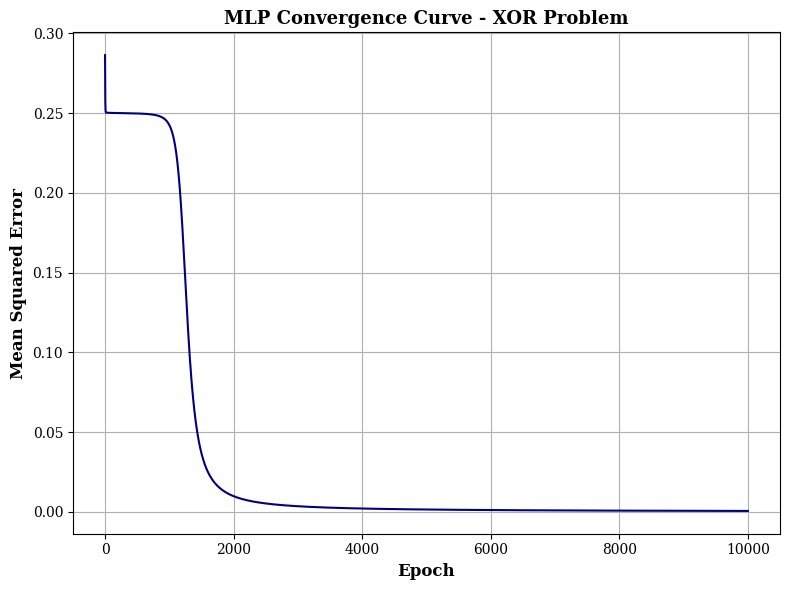

In [ ]:

def plot_convergence(loss_history, filename=None):
    plt.figure(figsize=(8, 6))
    plt.plot(loss_history, color='navy', linewidth=1.5)

    plt.xlabel("Epoch", fontweight='bold', fontsize=12)
    plt.ylabel("Mean Squared Error", fontweight='bold', fontsize=12)
    plt.title("MLP Convergence Curve - XOR Problem", fontweight='bold', fontsize=13)

    plt.grid(True)
    plt.tight_layout()

    if filename is not None:
        plt.savefig(filename, dpi=600, format="eps", bbox_inches="tight")
    plt.show()

plot_convergence(loss_history, filename="XOR_MLP_Convergence.eps")

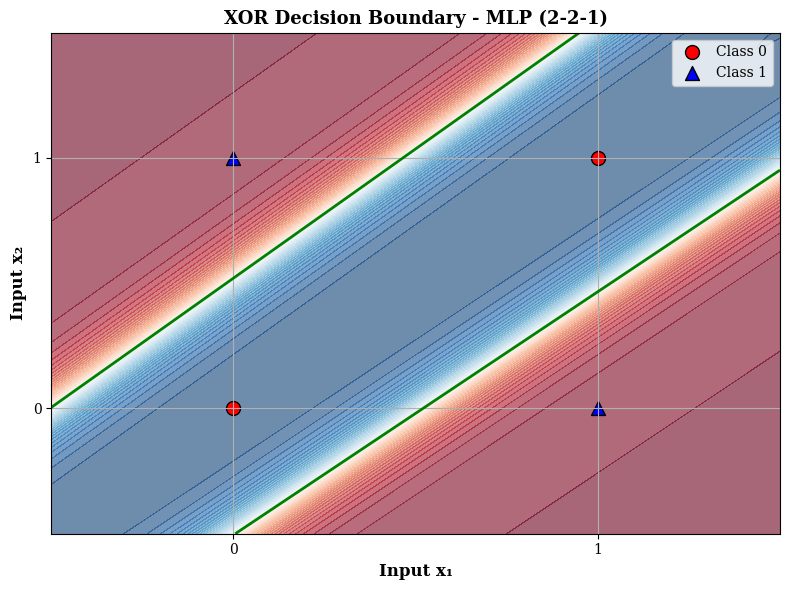

In [ ]:

def plot_mlp_decision_boundary(X, y, W1, b1, W2, b2, title, filename=None):
    plt.figure(figsize=(8, 6))

    x1_range = np.linspace(-0.5, 1.5, 300)
    x2_range = np.linspace(-0.5, 1.5, 300)
    xx1, xx2 = np.meshgrid(x1_range, x2_range)
    grid = np.c_[xx1.ravel(), xx2.ravel()]

    probs = predict(grid, W1, b1, W2, b2).reshape(xx1.shape)

    plt.contourf(xx1, xx2, probs, levels=50, cmap='RdBu_r', alpha=0.6)
    plt.contour(xx1, xx2, probs, levels=[0.5], colors='green', linewidths=2)

    y_flat = y.ravel()
    plt.scatter(X[y_flat == 0, 0], X[y_flat == 0, 1],
                color='red', marker='o', s=100, edgecolors='black', label='Class 0')
    plt.scatter(X[y_flat == 1, 0], X[y_flat == 1, 1],
                color='blue', marker='^', s=100, edgecolors='black', label='Class 1')

    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)
    plt.xticks([0, 1])
    plt.yticks([0, 1])

    plt.xlabel("Input x\u2081", fontweight='bold', fontsize=12)
    plt.ylabel("Input x\u2082", fontweight='bold', fontsize=12)
    plt.title(title, fontweight='bold', fontsize=13)

    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    if filename is not None:
        plt.savefig(filename, dpi=600, format="eps", bbox_inches="tight")
    plt.show()

plot_mlp_decision_boundary(X_mlp, y_mlp, W1, b1, W2, b2,
                            "XOR Decision Boundary - MLP (2-2-1)",
                            filename="XOR_MLP_DecisionBoundary.eps")